In [1]:
import os

MODEL_PATH = "/kaggle/input/models/rajeshwarigolande/best/keras/default/1"

print("Files inside model path:")
print(os.listdir(MODEL_PATH))

Files inside model path:
['best_model_87.9.keras']


In [2]:
# ==============================
# 📌 LOAD MODEL (FINAL FIX)
# ==============================
import tensorflow as tf

MODEL_PATH = "/kaggle/input/models/rajeshwarigolande/best/keras/default/1/best_model_87.9.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model Loaded Successfully")

2026-04-02 14:05:19.199391: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775138719.386584      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775138719.439052      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775138719.868647      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775138719.868695      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775138719.868699      55 computation_placer.cc:177] computation placer alr

✅ Model Loaded Successfully


In [4]:
IMG_SIZE = 224   # ✅ FIXED

X = []
y = []

for file in os.listdir(DATASET_PATH):
    img_path = os.path.join(DATASET_PATH, file)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    # Resize to correct size
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize
    img = img / 255.0

    # Add channel dimension
    img = np.expand_dims(img, axis=-1)

    X.append(img)

    # Label extraction
    if "__M_" in file:
        y.append(0)
    elif "__F_" in file:
        y.append(1)

X = np.array(X, dtype=np.float32)   # ensure correct dtype
y = np.array(y)

print("Shape of X:", X.shape)   # should be (6000, 224, 224, 1)

Shape of X: (6000, 224, 224, 1)


In [5]:
y_pred_probs = model.predict(X)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

print("✅ Predictions Generated")

I0000 00:00:1775139074.625582     126 service.cc:152] XLA service 0x78ed980033f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775139074.625642     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775139075.598188     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775139082.195205     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 72ms/step
✅ Predictions Generated


In [8]:
y_pred_probs = model.predict(X)

print("Prediction shape:", y_pred_probs.shape)  # should be (6000, 2)

# Convert probabilities → class labels
y_pred = np.argmax(y_pred_probs, axis=1)

print("y shape:", y.shape)
print("y_pred shape:", y_pred.shape)

188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step
Prediction shape: (6000, 2)
y shape: (6000,)
y_pred shape: (6000,)


Original y sample: [0 1 1 0 0 0 1 0 0 1]
Fixed y sample   : [1 0 0 1 1 1 0 1 1 0]

📊 ===== FIXED MODEL METRICS =====
Accuracy  : 0.9013
Precision : 0.9017
Recall    : 0.9830
F1 Score  : 0.9406

📄 ===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        Male       0.90      0.58      0.71      1230
      Female       0.90      0.98      0.94      4770

    accuracy                           0.90      6000
   macro avg       0.90      0.78      0.82      6000
weighted avg       0.90      0.90      0.89      6000


🔢 Confusion Matrix:
 [[ 719  511]
 [  81 4689]]


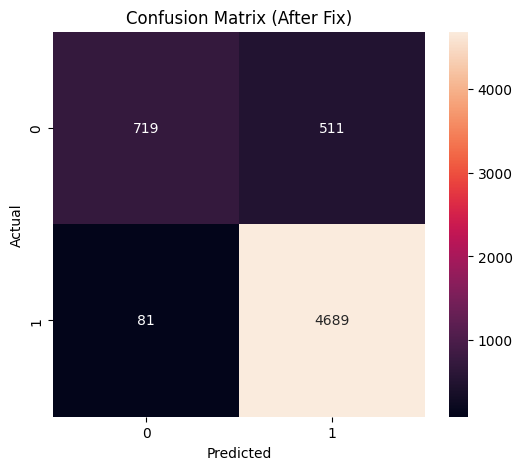

In [10]:
# ==============================
# 📌 FIX LABEL MISMATCH
# ==============================

# Flip labels (Male <-> Female)
y_fixed = 1 - y

print("Original y sample:", y[:10])
print("Fixed y sample   :", y_fixed[:10])


# ==============================
# 📌 RECOMPUTE METRICS
# ==============================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_fixed, y_pred)
precision = precision_score(y_fixed, y_pred)
recall = recall_score(y_fixed, y_pred)
f1 = f1_score(y_fixed, y_pred)

print("\n📊 ===== FIXED MODEL METRICS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# ==============================
# 📌 CLASSIFICATION REPORT
# ==============================
from sklearn.metrics import classification_report, confusion_matrix

print("\n📄 ===== CLASSIFICATION REPORT =====")
print(classification_report(y_fixed, y_pred, target_names=["Male", "Female"]))


# ==============================
# 📌 CONFUSION MATRIX
# ==============================
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_fixed, y_pred)

print("\n🔢 Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (After Fix)")
plt.show()

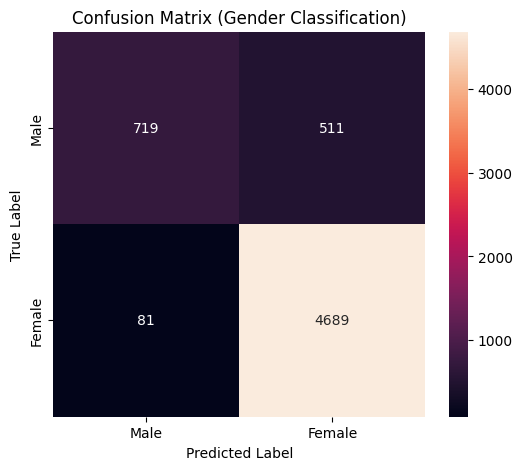

✅ Confusion matrix saved at: confusion_matrix.png


In [11]:
# ==============================
# 📌 SAVE CONFUSION MATRIX IMAGE
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_fixed, y_pred)

# Labels
labels = ["Male", "Female"]

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Gender Classification)")

# Save image
save_path = "confusion_matrix.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"✅ Confusion matrix saved at: {save_path}")

📊 AUC Score: 0.9337


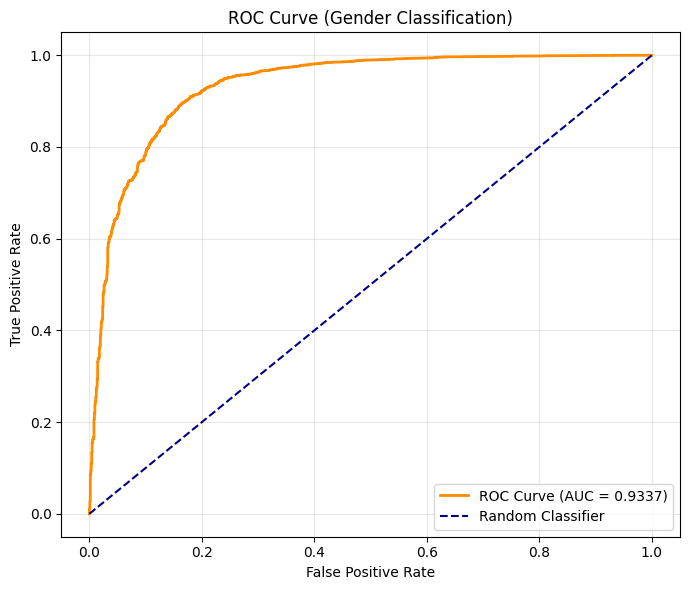

✅ ROC curve saved at: roc_curve.png


In [18]:
# ==============================
# 📌 AUC / ROC CURVE
# ==============================
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Use probability of the positive class (Female = class 1)
y_score = y_pred_probs[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_fixed, y_score)
roc_auc = auc(fpr, tpr)

print(f"📊 AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Gender Classification)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()

# Save image
save_path = "roc_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ ROC curve saved at: {save_path}")

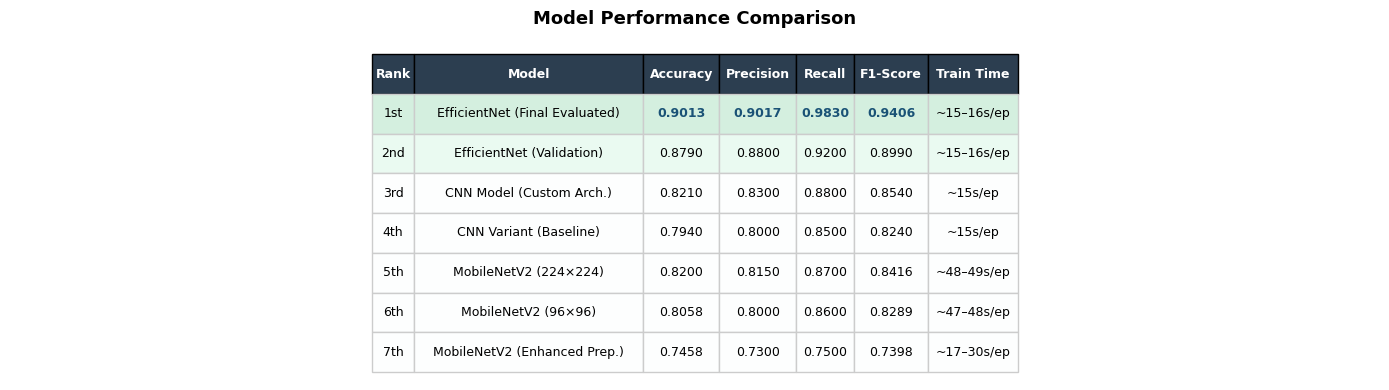

✅ Comparison table saved as model_comparison_table.png


In [19]:
# ==============================
# 📌 MODEL COMPARISON TABLE
# ==============================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data
models = [
    "EfficientNet\n(Final Evaluated)",
    "EfficientNet\n(Validation)",
    "CNN Model\n(Custom Arch.)",
    "CNN Variant\n(Baseline)",
    "MobileNetV2\n(224×224)",
    "MobileNetV2\n(96×96)",
    "MobileNetV2\n(Enhanced Prep.)"
]

ranks       = ["1st", "2nd", "3rd", "4th", "5th", "6th", "7th"]
accuracy    = [0.9013, 0.8790, 0.8210, 0.7940, 0.8200, 0.8058, 0.7458]
precision   = [0.9017, 0.8800, 0.8300, 0.8000, 0.8150, 0.8000, 0.7300]
recall      = [0.9830, 0.9200, 0.8800, 0.8500, 0.8700, 0.8600, 0.7500]
f1          = [0.9406, 0.8990, 0.8540, 0.8240, 0.8416, 0.8289, 0.7398]
train_times = ["~15–16s/ep", "~15–16s/ep", "~15s/ep", "~15s/ep", "~48–49s/ep", "~47–48s/ep", "~17–30s/ep"]

# Table content
col_labels = ["Rank", "Model", "Accuracy", "Precision", "Recall", "F1-Score", "Train Time"]
table_data = []
for i in range(len(models)):
    table_data.append([
        ranks[i],
        models[i].replace("\n", " "),
        f"{accuracy[i]:.4f}",
        f"{precision[i]:.4f}",
        f"{recall[i]:.4f}",
        f"{f1[i]:.4f}",
        train_times[i]
    ])

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

# --- Style header ---
header_color = "#2c3e50"
for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor(header_color)
    cell.set_text_props(color="white", fontweight="bold")

# --- Row colors: highlight top model, alternate rest ---
row_colors = ["#d4efdf", "#eafaf1", "#fdfefe", "#fdfefe", "#fdfefe", "#fdfefe", "#fdfefe"]  # green tint for 1st
for i, row_color in enumerate(row_colors):
    for j in range(len(col_labels)):
        cell = table[i + 1, j]
        cell.set_facecolor(row_color)
        cell.set_edgecolor("#cccccc")

# --- Bold best metric values per column (cols 2–5) ---
best_idx = {
    2: accuracy.index(max(accuracy)),
    3: precision.index(max(precision)),
    4: recall.index(max(recall)),
    5: f1.index(max(f1)),
}
for col_idx, row_idx in best_idx.items():
    table[row_idx + 1, col_idx].set_text_props(fontweight="bold", color="#1a5276")

# --- Column widths ---
col_widths = [0.05, 0.22, 0.09, 0.09, 0.09, 0.09, 0.12]
for j, w in enumerate(col_widths):
    table.auto_set_column_width(j)

plt.title("Model Performance Comparison", fontsize=13, fontweight="bold", pad=16)
plt.tight_layout()
plt.savefig("model_comparison_table.png", dpi=200, bbox_inches="tight")
plt.show()

print("✅ Comparison table saved as model_comparison_table.png")

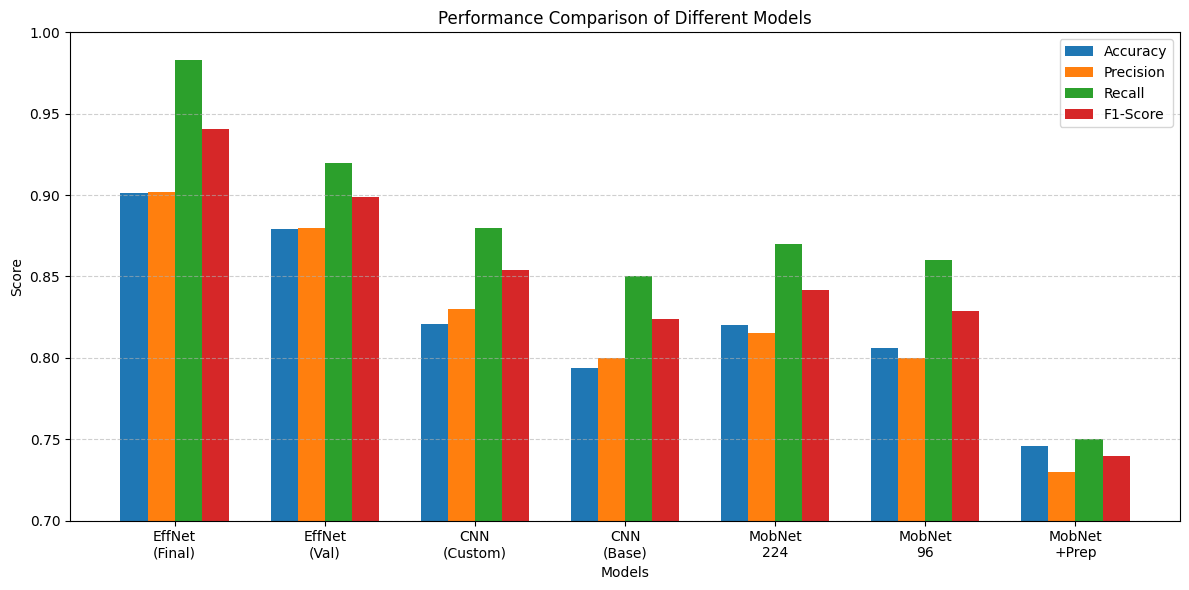

✅ Bar plot saved at: /kaggle/working/model_comparison_barplot.png


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import os

# -----------------------------
# Data
# -----------------------------
models = [
    "EffNet\n(Final)",
    "EffNet\n(Val)",
    "CNN\n(Custom)",
    "CNN\n(Base)",
    "MobNet\n224",
    "MobNet\n96",
    "MobNet\n+Prep"
]

accuracy  = [0.9013, 0.8790, 0.8210, 0.7940, 0.8200, 0.8058, 0.7458]
precision = [0.9017, 0.8800, 0.8300, 0.8000, 0.8150, 0.8000, 0.7300]
recall    = [0.9830, 0.9200, 0.8800, 0.8500, 0.8700, 0.8600, 0.7500]
f1        = [0.9406, 0.8990, 0.8540, 0.8240, 0.8416, 0.8289, 0.7398]

# -----------------------------
# Plot setup
# -----------------------------
x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(12, 6))

# Bars
plt.bar(x - 1.5*width, accuracy,  width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall,    width, label='Recall')
plt.bar(x + 1.5*width, f1,        width, label='F1-Score')

# -----------------------------
# Styling
# -----------------------------
plt.xticks(x, models)
plt.ylabel("Score")
plt.xlabel("Models")
plt.title("Performance Comparison of Different Models")
plt.ylim(0.7, 1.0)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# # -----------------------------
# # Highlight best model
# # -----------------------------
# best_idx = 0  # EfficientNet Final
# for i in range(4):
#     plt.text(x[best_idx] - 1.5*width + i*width,
#              accuracy[best_idx] + 0.01,
#              "★",
#              ha='center')

# -----------------------------
# Save figure
# -----------------------------
save_path = os.path.join(os.getcwd(), "model_comparison_barplot.png")
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

print("✅ Bar plot saved at:", save_path)

In [24]:
from IPython.display import display
from ipywidgets import FileUpload

upload = FileUpload(accept='image/*', multiple=False)
display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

In [27]:
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Get uploaded file (FIXED)
uploaded_file = upload.value[0]

# Extract content
content = uploaded_file['content']

# Save image
img_path = "uploaded_image.jpg"
with open(img_path, "wb") as f:
    f.write(content)

print("✅ Image uploaded and saved as:", img_path)

✅ Image uploaded and saved as: uploaded_image.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
✅ Predicted class: 1
✅ Using layer: conv2d


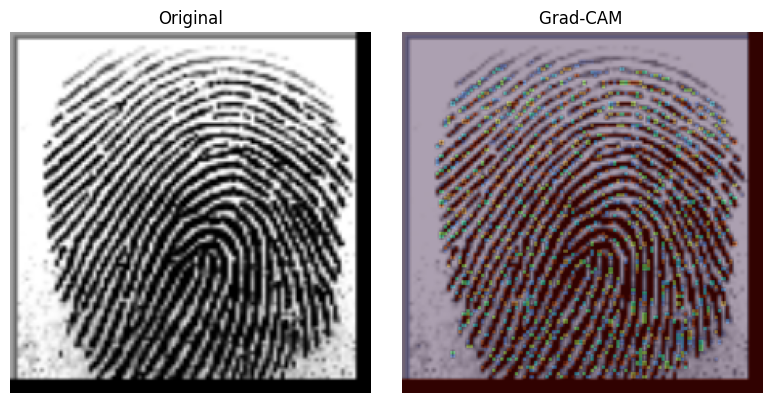

🔥 Grad-CAM saved at: /kaggle/working/gradcam_output.png


In [36]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# -----------------------------
# STEP 1: Image path
# -----------------------------
img_path = "uploaded_image.jpg"

# -----------------------------
# STEP 2: Load & preprocess (GRAYSCALE)
# -----------------------------
img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(224, 224),
    color_mode='grayscale'
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# -----------------------------
# STEP 3: Prediction
# -----------------------------
preds = model.predict(img_array)
class_idx = np.argmax(preds[0])

print("✅ Predicted class:", class_idx)

# -----------------------------
# STEP 4: Find last conv layer
# -----------------------------
last_conv_layer = None
for layer in reversed(model.layers):
    try:
        if "conv" in layer.name.lower() and len(layer.output.shape) == 4:
            last_conv_layer = layer.name
            break
    except:
        continue

if last_conv_layer is None:
    raise ValueError("❌ No convolutional layer found.")

print("✅ Using layer:", last_conv_layer)

# -----------------------------
# STEP 5: Grad-CAM core
# -----------------------------
grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.get_layer(last_conv_layer).output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# -----------------------------
# 🔥 STEP 6: STRONG NORMALIZATION (FIXES ALL-RED)
# -----------------------------
heatmap = np.maximum(heatmap, 0)

# Standardize (KEY FIX)
mean = np.mean(heatmap)
std = np.std(heatmap) + 1e-8
heatmap = (heatmap - mean) / std

# Keep only positive activations
heatmap = np.clip(heatmap, 0, None)

# Normalize to 0–1
if np.max(heatmap) != 0:
    heatmap /= np.max(heatmap)

# Enhance contrast (VERY IMPORTANT)
heatmap = np.power(heatmap, 2)

# -----------------------------
# STEP 7: Overlay
# -----------------------------
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224, 224))

# Convert to 3-channel
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

# 🔥 Best colormap for contrast
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_TURBO)

# Overlay
superimposed_img = cv2.addWeighted(img_color, 0.6, heatmap, 0.4, 0)

# -----------------------------
# STEP 8: Display & Save
# -----------------------------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Grad-CAM ")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()

save_path = os.path.join(os.getcwd(), "gradcam_output.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

print("🔥 Grad-CAM saved at:", save_path)